# hsc0021 daily precipitation demo

This notebook demonstrates how to read Hans' `hsc0021.zarr` daily precipitation data, convert `pr` to `mm/day`, derive HEALPix lon/lat coordinates, and prepare a simple longitude-time field for spectra or Hovmoller plots.

Important: `z0` to `z11` are HEALPix spatial refinement levels, not time segments. Choose one level; do not concatenate them along time.

In [14]:
from pathlib import Path
from typing import Tuple, List, Optional, Union, Dict
import healpy as hp
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import os,sys
import cmaps
# 将 cartopy 海岸线几何体转换为经纬度路径，手动投影到 mollview 坐标
from pathlib import Path
from matplotlib.path import Path as MplPath
from matplotlib.patches import PathPatch

WAVE_TOOLS_PATH = Path("/work/mh1498/m301257/wave_tools")
sys.path.insert(0, str(WAVE_TOOLS_PATH.parent))
from wave_tools.utils import dataarray_healpix_to_equatorial_latlon

import cartopy.crs as ccrs
import matplotlib.ticker as mticker
import cartopy.feature as cfeature


ROOT = Path('/work/mh1498/m300876/icon_ver13052026/icon-mpim/experiments/hsc0021/outdata/hsc0021.zarr')

# Use a modest level for interactive testing. z8 is still manageable for many tasks;
# z11 is very large and should be streamed/block-processed.
LEVEL = 8
GROUP = ROOT / f'P1D_mean_z{LEVEL}'

ds = xr.open_zarr(GROUP, consolidated=False, zarr_format=3)
ds

<xarray.Dataset> Size: 44GB
Dimensions:                (time: 426, cell: 786432, soil_level: 5, crs: 1)
Coordinates:
  * time                   (time) datetime64[ns] 3kB 2020-01-02 ... 2021-03-02
  * soil_level             (soil_level) int64 40B 1 2 3 4 5
  * crs                    (crs) float32 4B 0.0
Dimensions without coordinates: cell
Data variables: (12/29)
    clivi                  (time, cell) float32 1GB dask.array<chunksize=(1, 196608), meta=np.ndarray>
    qgvi                   (time, cell) float32 1GB dask.array<chunksize=(1, 196608), meta=np.ndarray>
    uas                    (time, cell) float32 1GB dask.array<chunksize=(1, 196608), meta=np.ndarray>
    rlut                   (time, cell) float32 1GB dask.array<chunksize=(1, 196608), meta=np.ndarray>
    hfls                   (time, cell) float32 1GB dask.array<chunksize=(1, 196608), meta=np.ndarray>
    rsds                   (time, cell) float32 1GB dask.array<chunksize=(1, 196608), meta=np.ndarray>
    ...                     ...
    tauu                   (time, cell) float32 1GB dask.array<chunksize=(1, 196608), meta=np.ndarray>
    evspsbl                (time, cell) float32 1GB dask.array<chunksize=(1, 196608), meta=np.ndarray>
    qsvi                   (time, cell) float32 1GB dask.array<chunksize=(1, 196608), meta=np.ndarray>
    vas                    (time, cell) float32 1GB dask.array<chunksize=(1, 196608), meta=np.ndarray>
    ts                     (time, cell) float32 1GB dask.array<chunksize=(1, 196608), meta=np.ndarray>
    clwvi                  (time, cell) float32 1GB dask.array<chunksize=(1, 196608), meta=np.ndarray>
Attributes:
    hiopy::parent:  P1D_mean_z9

In [15]:
print('daily variables:')
print(', '.join(ds.data_vars))
print()
print('time range:', ds.time.values[0], 'to', ds.time.values[-1])
print('ntime:', ds.sizes['time'])
print('ncell:', ds.sizes['cell'])
print('pr attrs:', ds.pr.attrs)

daily variables:
clivi, qgvi, uas, rlut, hfls, rsds, psl, qrvi, sic, rlds, rsus, prw, tas, qv2m, hfss, rsut, rsdt, tauv, clt, hydro_wtr_soil_sl_box, rlus, ps, pr, tauu, evspsbl, qsvi, vas, ts, clwvi

time range: 2020-01-02T00:00:00.000000000 to 2021-03-02T00:00:00.000000000
ntime: 426
ncell: 786432
pr attrs: {'hiopy::interpolation_stack': '- nnn:\n    n: 4', '_ARRAY_DIMENSIONS': ['time', 'cell'], 'grid_mapping': 'crs', 'hiopy::time_method': 'mean', 'hiopy::enable': True, 'standard_name': 'pr', 'units': 'kg m-2 s-1', 'short_name': '', 'long_name': 'precipitation flux'}


In [16]:


def dataarray_to_equatorial_latlon_grid(
    dataarray: xr.DataArray, grid_type: str, grid_dict: Optional[dict]
) -> xr.DataArray:
    """转换数据到赤道经纬度网格"""
    if grid_type == "latlon":
        return dataarray
    elif grid_type == "healpix":
        if grid_dict is None:
            raise ValueError("No grid_dict provided for healpix conversion.")
        
        # 检查是否有时间维度
        has_time = 'time' in dataarray.dims
        
        if not has_time:
            # 如果没有时间维度，添加一个虚拟的时间维度
            dataarray_with_time = dataarray.expand_dims(time=[np.datetime64('1980-01-01')])
            result = dataarray_healpix_to_equatorial_latlon(dataarray_with_time, **grid_dict)
            # 移除虚拟的时间维度
            result = result.squeeze('time', drop=True)
            return result
        else:
            return dataarray_healpix_to_equatorial_latlon(dataarray, **grid_dict)
    else:
        raise ValueError("Grid type not found.")


## Convert precipitation to mm/day

`pr` is stored as precipitation flux in `kg m-2 s-1`. Multiplying by `86400` gives daily precipitation in `mm/day`.

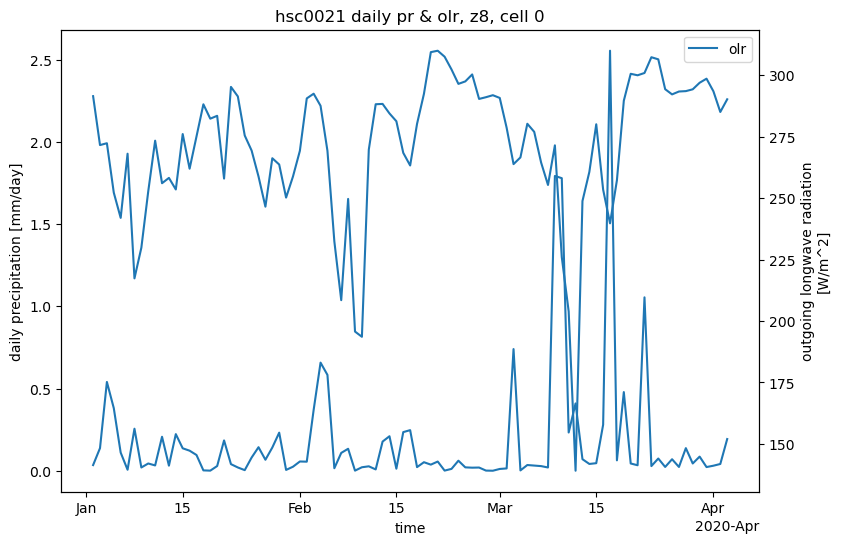

In [17]:
pr = (ds['pr'] * 86400.0).rename('pr')
pr.attrs.update(units='mm/day', long_name='daily precipitation')
olr = (ds['rlut']).rename('olr')
olr.attrs.update(units='W/m^2', long_name='outgoing longwave radiation')
# Load a single cell time series as a small sanity check.
ts0 = pr.isel(cell=0).load()
olr0 = olr.isel(cell=0).load()
plt.figure(figsize=(9, 6))
ax = plt.gca()
ts0.plot(ax=ax, label='pr')
ax2 = ax.twinx()
olr0.plot(ax=ax2, label='olr')
plt.title(f'hsc0021 daily pr & olr, z{LEVEL}, cell 0')
plt.legend()
plt.show()

## HEALPix cell centers

The grid is HEALPix with `nested` indexing. At level `z`, `nside = 2**z` and `ncell = 12 * nside**2`.

In [18]:
nside = 2 ** LEVEL
cells = np.arange(ds.sizes['cell'], dtype=np.int64)
lon, lat = hp.pix2ang(nside, cells, nest=True, lonlat=True)

print('nside:', nside)
print('lon range:', lon.min(), lon.max())
print('lat range:', lat.min(), lat.max())

nside: 256
lon range: 0.0 359.82421875
lat range: -89.81725848475486 89.81725848475484


In [19]:
grid_dict = {"nside": 256, "nest": True, "minmax_lat": 90}

In [20]:
olr

<xarray.DataArray 'olr' (time: 426, cell: 786432)> Size: 1GB
dask.array<open_dataset-rlut, shape=(426, 786432), dtype=float32, chunksize=(1, 196608), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 3kB 2020-01-02 2020-01-03 ... 2021-03-02
Dimensions without coordinates: cell
Attributes:
    hiopy::interpolation_stack:  - nnn:\n    n: 4
    _ARRAY_DIMENSIONS:           ['time', 'cell']
    grid_mapping:                crs
    hiopy::time_method:          mean
    hiopy::enable:               True
    standard_name:               toa_outgoing_longwave_flux
    units:                       W/m^2
    short_name:                  
    long_name:                   outgoing longwave radiation

In [21]:
olr_latlon = dataarray_to_equatorial_latlon_grid(olr, grid_type='healpix', grid_dict=grid_dict)

DEBUG: Total pixels: 786432
DEBUG: Lat range: -89.82 to 89.82
DEBUG: Lon range: 0.00 to 359.82
DEBUG: Unique latitudes in range: 1023
DEBUG: Reference latitude: -41.81, with 1024 longitude points
  Lat -89.8173: 4 points, target: 1024 points
    -> Interpolated to 1024 points
  Lat -89.6345: 8 points, target: 1024 points
    -> Interpolated to 1024 points
  Lat -89.4518: 12 points, target: 1024 points
    -> Interpolated to 1024 points
  Lat 89.8173: 4 points, target: 1024 points


In [22]:
def to_hp_array(da, mask=None):
    arr = np.asarray(da.values, dtype=np.float64)
    if mask is None:
        return arr
    out = arr.copy()
    out[~mask] = hp.UNSEEN
    return out

npix = olr.sizes["cell"]
nside = hp.npix2nside(npix)
print("npix =", npix)
print("nside =", nside)

npix = 786432
nside = 256


/tmp/ipykernel_1027598/2159014362.py:47: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


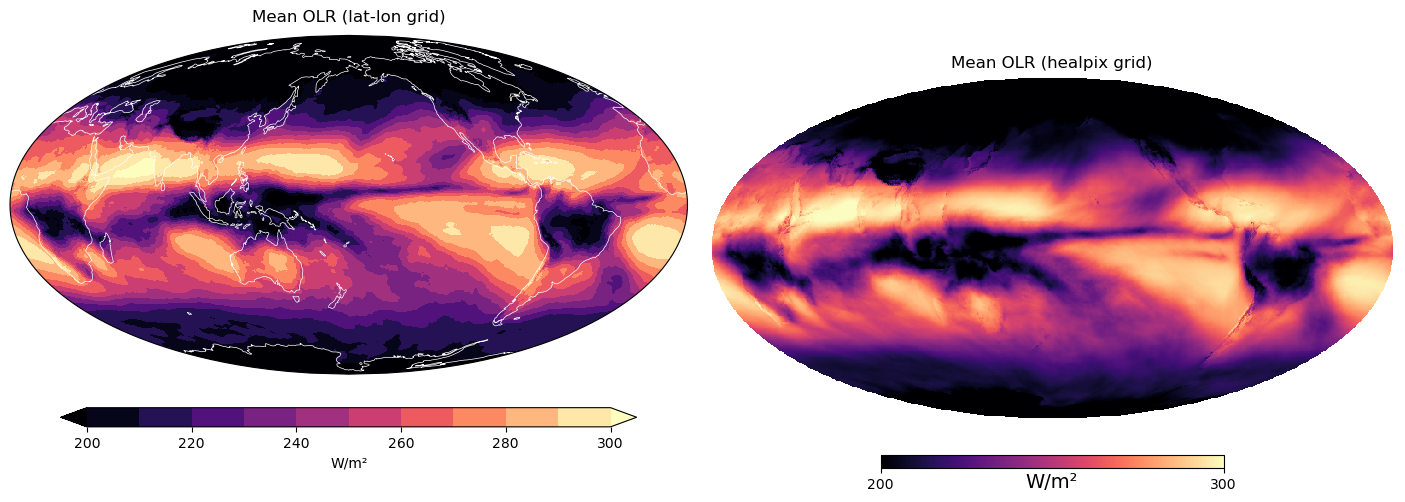

In [23]:


fig = plt.figure(figsize=(14, 7))

# ── 子图1：lat-lon → Mollweide 投影 ──────────────────────────────────
ax1 = fig.add_subplot(1, 2, 1, projection=ccrs.Mollweide(central_longitude=180))

data = olr_latlon.mean('time')
lons = data.lon.values
lats = data.lat.values

im = ax1.contourf(
    lons, lats, data.values,
    levels=np.arange(200, 310, 10),
    cmap='magma',
    vmin=200, vmax=300,
    transform=ccrs.PlateCarree(),   # 数据本身是经纬度坐标
    extend='both',
)
ax1.set_global()
ax1.coastlines(linewidth=0.5, color='white')
ax1.set_title('Mean OLR (lat-lon grid)', pad=10)

# colorbar 放在子图下方
cbar1 = fig.colorbar(
    im, ax=ax1,
    orientation='horizontal',
    pad=0.05, shrink=0.85, aspect=30,
    label='W/m²',
)
cbar1.set_ticks(np.arange(200, 310, 20))

# ── 子图2：HEALPix → Mollweide（mollview 内置）────────────────────────
hp.mollview(
    to_hp_array(olr.mean("time").compute()),
    nest=True,
    sub=(1, 2, 2),
    fig=fig.number,
    min=200, max=300,
    cmap='magma',
    title='Mean OLR (healpix grid)',
    unit='W/m²',
    cbar=True,
    flip="geo",
    notext=True,
    rot=(180, 0, 0),
)

plt.tight_layout()
plt.show()

/tmp/ipykernel_1027598/4250591935.py:42: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


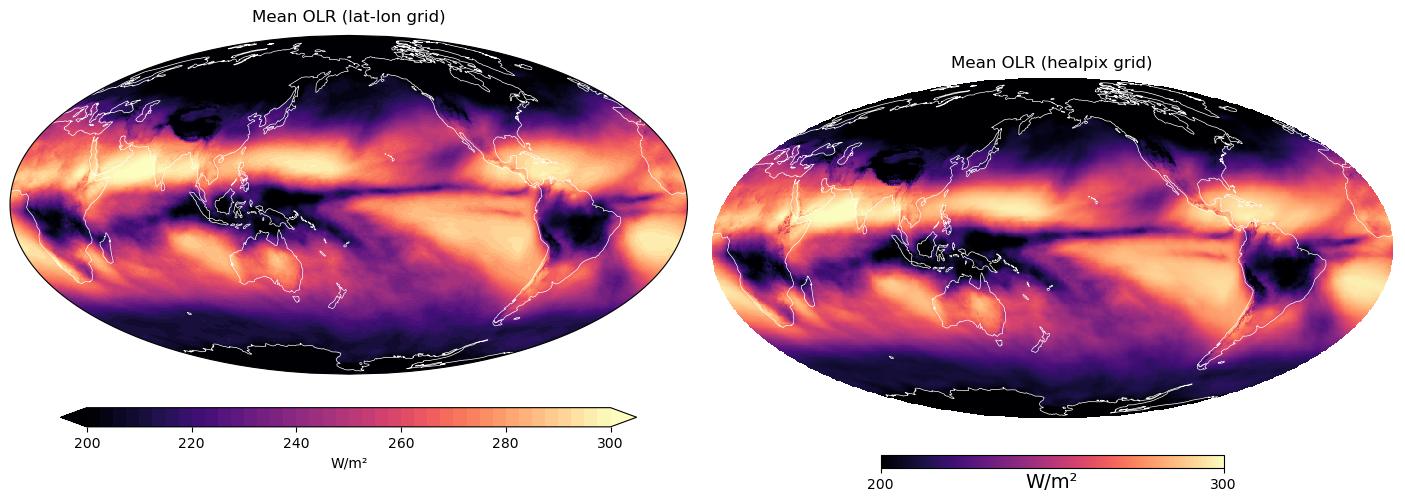

In [25]:

fig = plt.figure(figsize=(14, 7))

# ── 子图1：lat-lon → Mollweide ──────────────────────────────────────
ax1 = fig.add_subplot(1, 2, 1, projection=ccrs.Mollweide(central_longitude=180))
data = olr_latlon.mean('time')
im = ax1.contourf(
    data.lon.values, data.lat.values, data.values,
    levels=np.linspace(200, 300, 41),
    cmap='magma', vmin=200, vmax=300,
    transform=ccrs.PlateCarree(),
    extend='both',
)
ax1.set_global()
ax1.coastlines(linewidth=0.5, color='white')
ax1.set_title('Mean OLR (lat-lon grid)', pad=10)
cbar1 = fig.colorbar(im, ax=ax1, orientation='horizontal',
                     pad=0.05, shrink=0.85, aspect=30, label='W/m²')
cbar1.set_ticks(np.arange(200, 310, 20))

# ── 子图2：HEALPix mollview ─────────────────────────────────────────
hp.mollview(
    to_hp_array(olr.mean("time").compute()),
    nest=True, sub=(1, 2, 2), fig=fig.number,
    min=200, max=300, cmap='magma',
    title='Mean OLR (healpix grid)',
    unit='W/m²', cbar=True, flip="geo",
    notext=True, rot=(180, 0, 0),
)

# ── 正确获取 healpy 的 HpxMollweideAxes ─────────────────────────────
ax2 = [ax for ax in fig.axes if hasattr(ax, 'projplot')][0]

# ── 叠加海岸线（用 projplot，直接传经纬度）───────────────────────────
for geom in cfeature.COASTLINE.geometries():
    geoms = geom.geoms if hasattr(geom, 'geoms') else [geom]
    for line in geoms:
        coords = np.array(line.coords)
        lon, lat = coords[:, 0], coords[:, 1]
        # healpy lonlat=True 模式：直接传经纬度（度），无需转换
        ax2.projplot(lon, lat, 'w-', linewidth=0.5, lonlat=True)

plt.tight_layout()
plt.show()